In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.utils import resample
from itertools import combinations

[1] (аналогично Заданию 2) Используя make_blobs с любым random_state,
сгенерировать датасет df, в котором есть три класса с размером каждого класса
100, четыре количественных (недискретных) признака ,а центры классов
зафиксированы в следующих точках: Класс 0 – (+1, +1, +1, +1), Класс 1 – (-1,-1,-1,-
1), Класс 2 – (-1,+1,-1,+1).

In [35]:
centers = [
  [+1, +1, +1, +1],
  [-1, -1, -1, -1],
  [-1, +1, -1, +1]
]

X, y = make_blobs(n_samples=300, centers=centers, random_state=1)

df = pd.DataFrame(X, columns=['feature_1', 'feature_2', 'feature_3', 'feature_4'])
df['target'] = y


[2] Не забываем повторять шаги с задания 1
- ключевые характеристики датасета, корреляции, визуализация на всех парах var

In [36]:
correlation_matrix = df.corr()
print("Матрица корреляций:\n")
print(correlation_matrix)

Матрица корреляций:

           feature_1  feature_2  feature_3  feature_4    target
feature_1   1.000000   0.134539   0.520941   0.155171 -0.616585
feature_2   0.134539   1.000000   0.295820   0.478983 -0.010461
feature_3   0.520941   0.295820   1.000000   0.300860 -0.599609
feature_4   0.155171   0.478983   0.300860   1.000000  0.018751
target     -0.616585  -0.010461  -0.599609   0.018751  1.000000


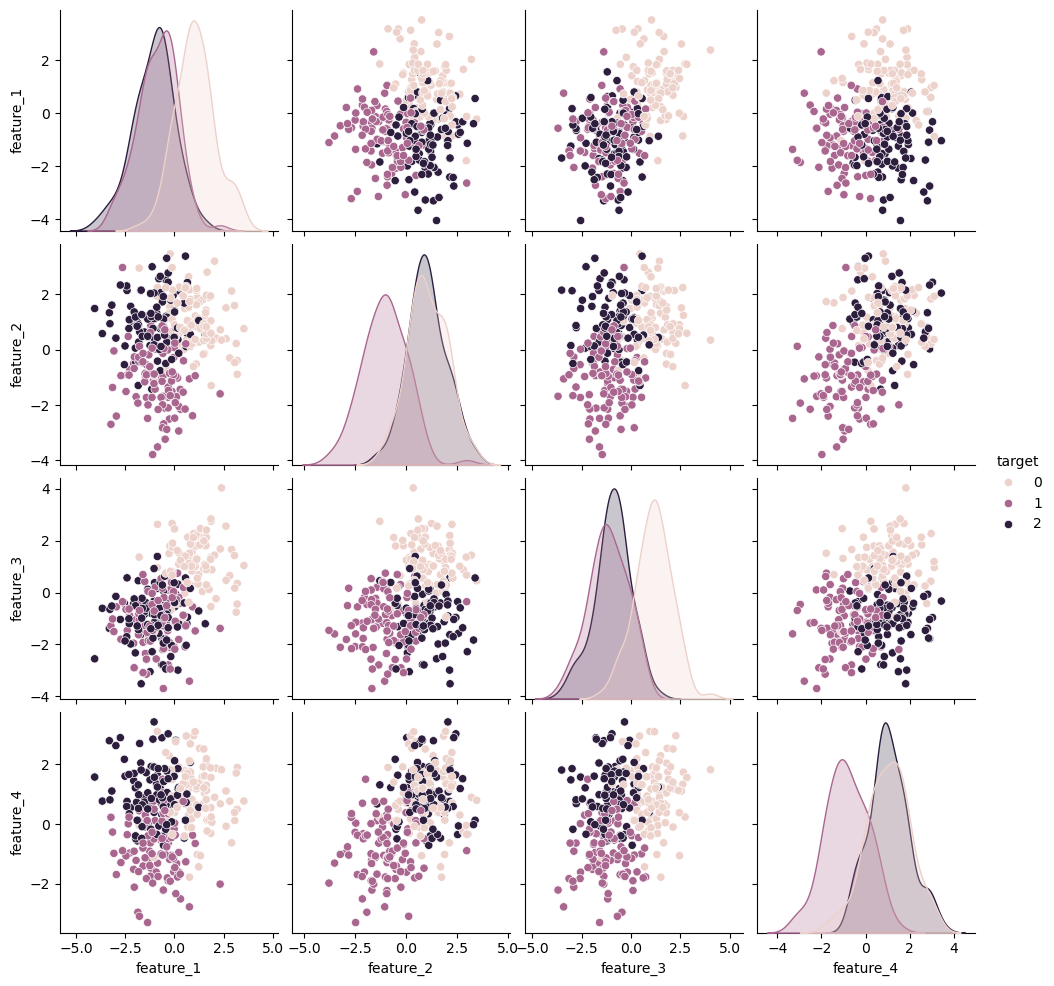

In [37]:
sns.pairplot(df, hue='target', diag_kind='kde')
plt.show()

[3] На основе созданного в пункте [1] датасета сгенерировать отдельные
дополнительные датасеты (df_A_B), в которых к классу 0 добавлено A одинаковых
точек с координатами (+B,-B,+B,-B), где A = 1, 10, 100 и B = 5, 10, 20, при этом
количество объектов в остальных классах неизменно.

In [43]:
datasets = {}
datasets['df_A0_B0'] = df.copy()

for A in [1, 10, 100]:
    for B in [5, 10, 20]:
        new_data = np.array([[+B, -B, +B, -B]] * A)
        new_labels = [0] * A

        df_A_B = df.copy()

        df_n = pd.DataFrame(new_data, columns=['feature_1', 'feature_2', 'feature_3', 'feature_4'])
        df_n['target'] = new_labels

        df_A_B = pd.concat([df_A_B, df_n], ignore_index=True)

        datasets[f'df_A{A}_B{B}'] = df_A_B

print(datasets)


{'df_A0_B0':      feature_1  feature_2  feature_3  feature_4  target
0    -0.857982   2.236164   2.627651   1.338012       0
1     0.524627   1.477610  -0.021886   1.794528       0
2     0.890009   1.008549   0.831801   0.825820       0
3    -0.419670   0.026732  -0.824832   0.946516       2
4    -2.067877   0.923321  -0.427037   1.457947       2
..         ...        ...        ...        ...     ...
295  -0.681986   0.109728  -0.888663   0.980477       2
296  -0.114174  -0.810138  -0.201936  -1.101932       1
297   0.961304  -0.615772   2.121418   1.408901       0
298  -2.637450   2.958603  -0.351356  -0.892657       1
299  -0.489062   0.710662  -0.965056   0.453918       1

[300 rows x 5 columns], 'df_A1_B5':      feature_1  feature_2  feature_3  feature_4  target
0    -0.857982   2.236164   2.627651   1.338012       0
1     0.524627   1.477610  -0.021886   1.794528       0
2     0.890009   1.008549   0.831801   0.825820       0
3    -0.419670   0.026732  -0.824832   0.946516       

[4] Выбрать пару классов (включая класс с повторенными объектами) и один
количественный признак.
Для каждого из датасетов df и df_A_B в своем пространстве Х-Y( количественный
признак-класс) построить и визуализировать объекты, линию линейной регрессии и
линию логистической регрессии. Регрессии строить на паре Х-Y( количественный
признак-класс).
Оценить качество работы полученных на основе логистической регрессии
классификаторов, используя ROC кривые, восстановив на графике ROC кривых
точку классификации Sensitivity-Specificity и доверительные интервалы CI95
бутстрепом (n=1000).
Все полученные графики возможно расположить в две колонки: левая колонка –
визуализация пространства и регрессий, правая – графики с ROC кривой и точкой.

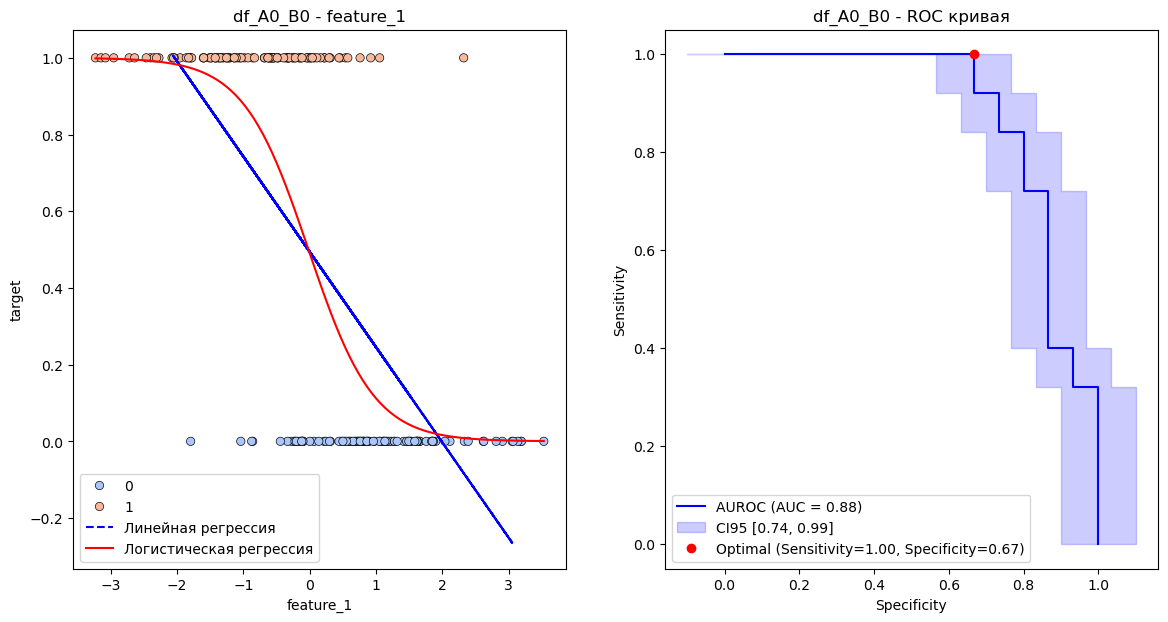

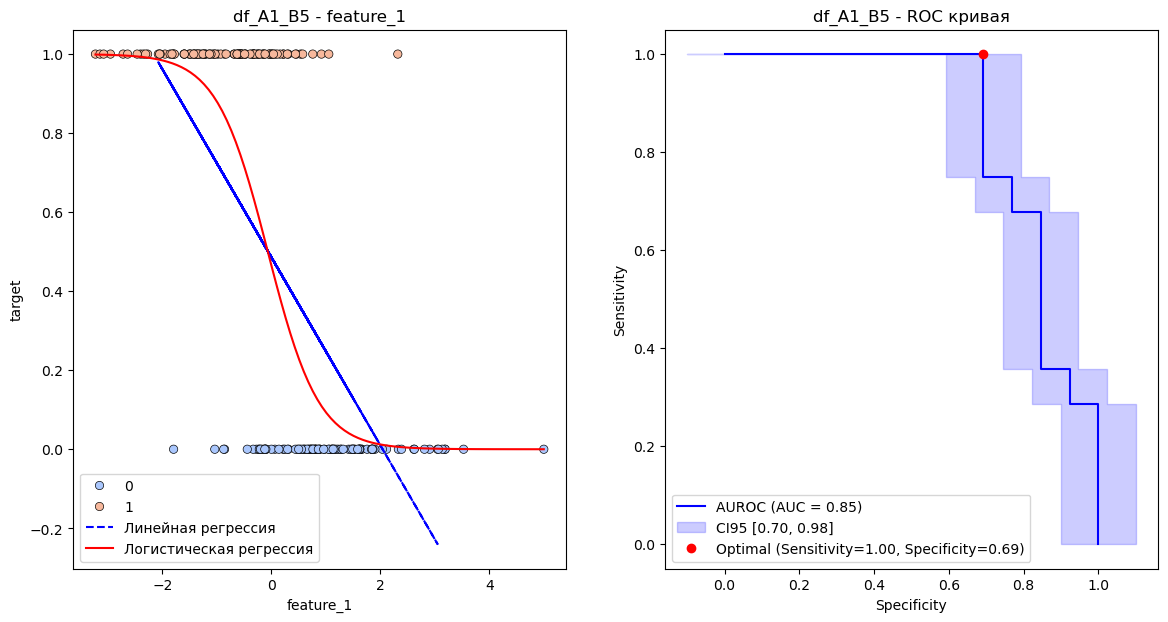

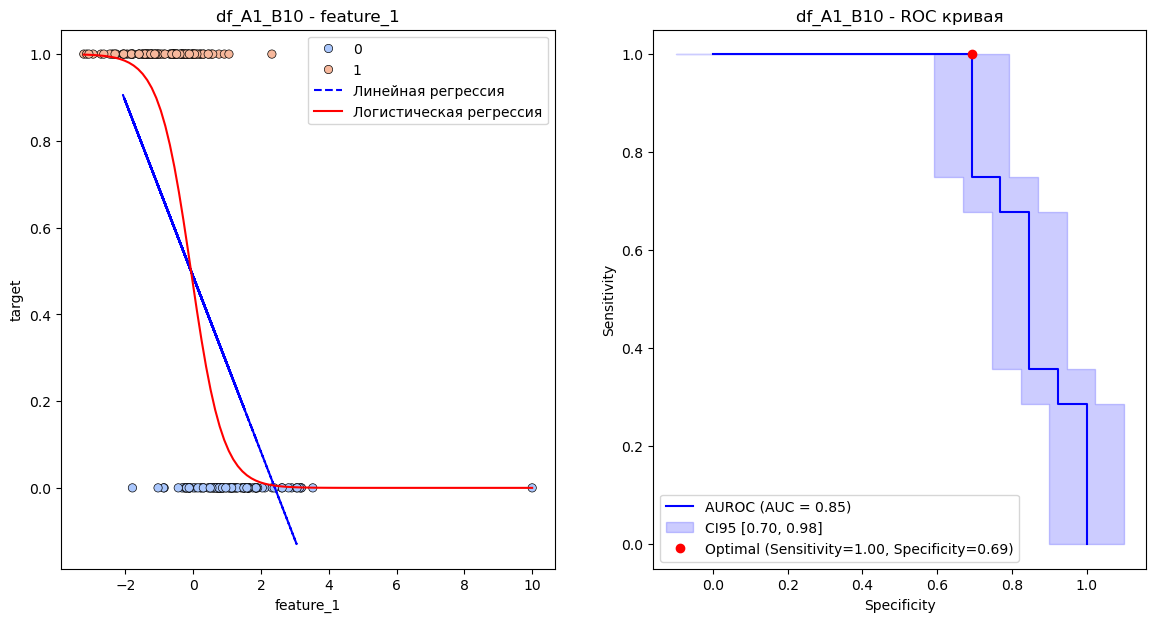

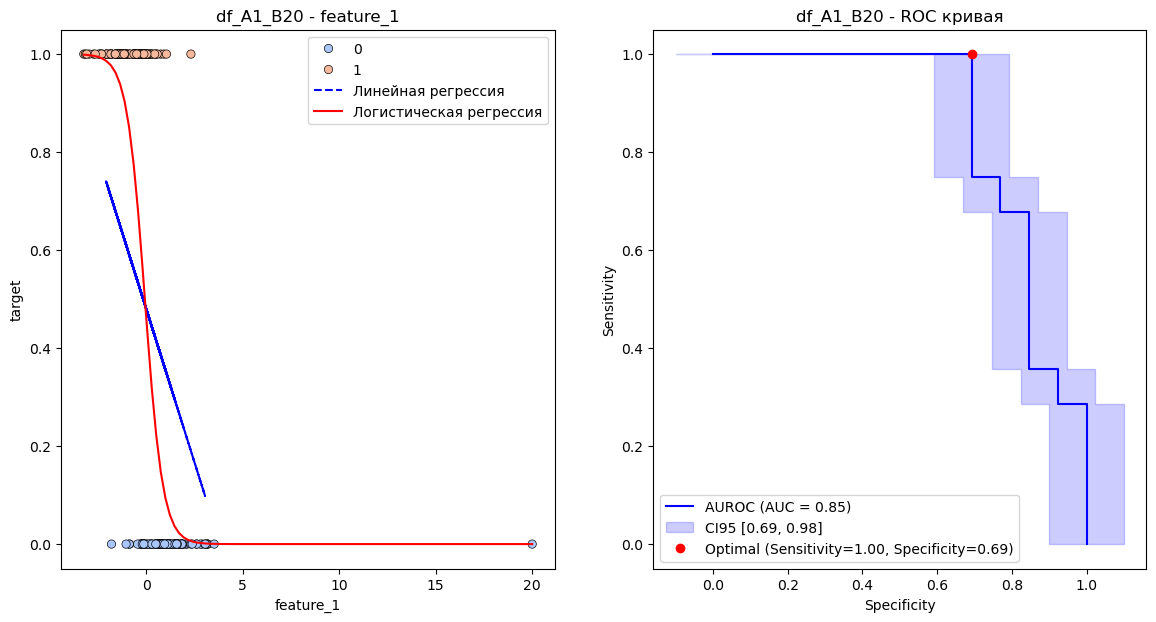

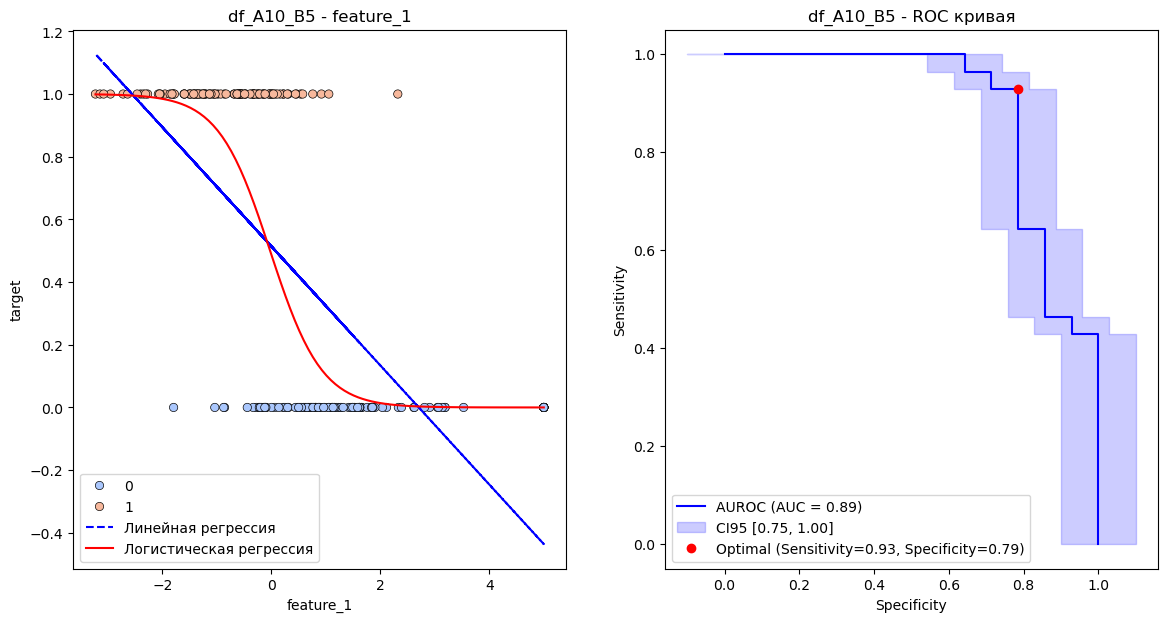

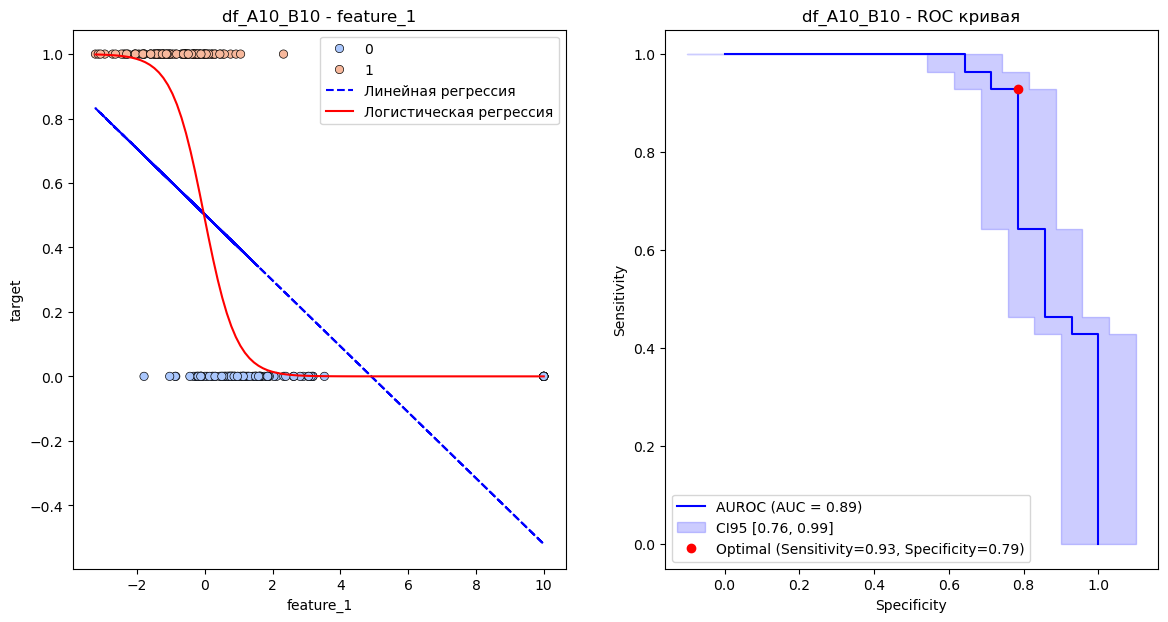

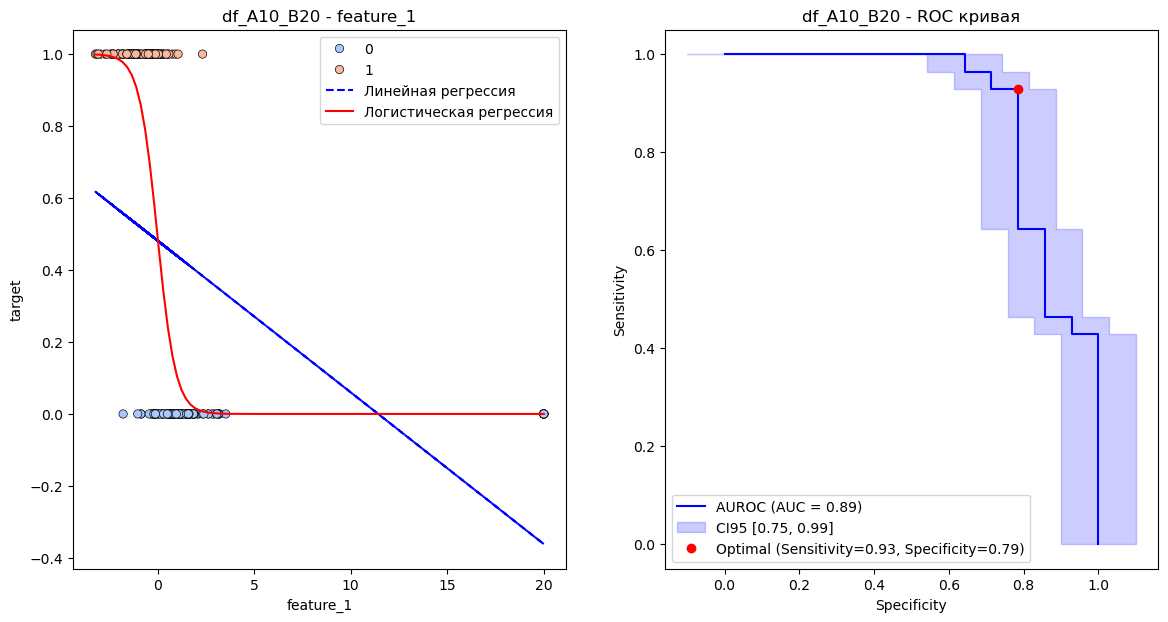

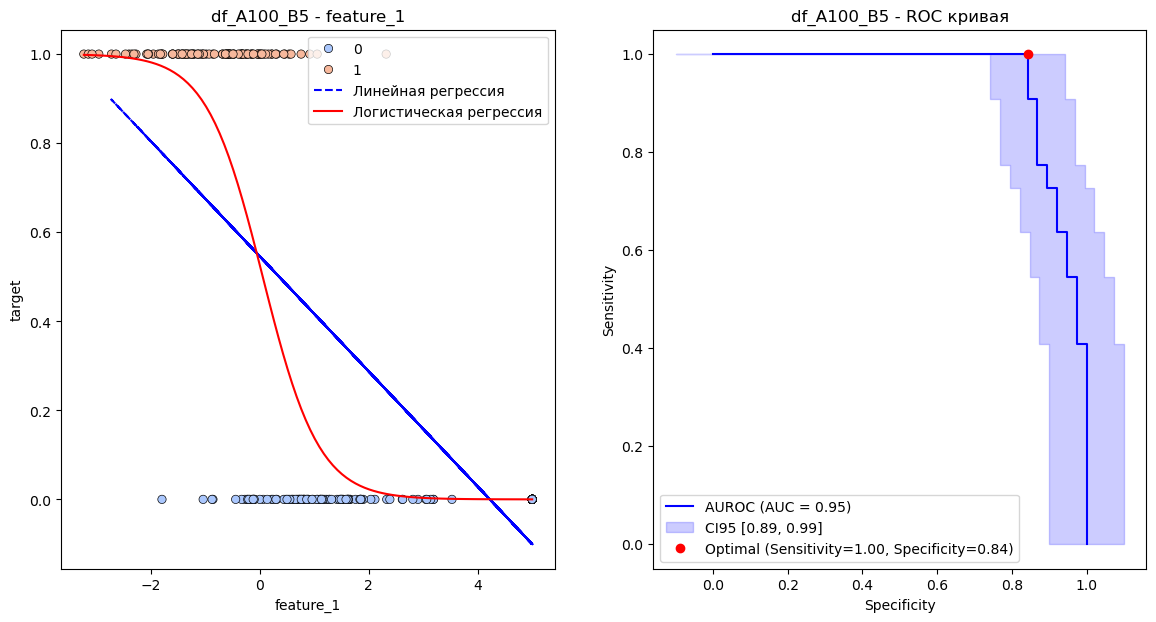

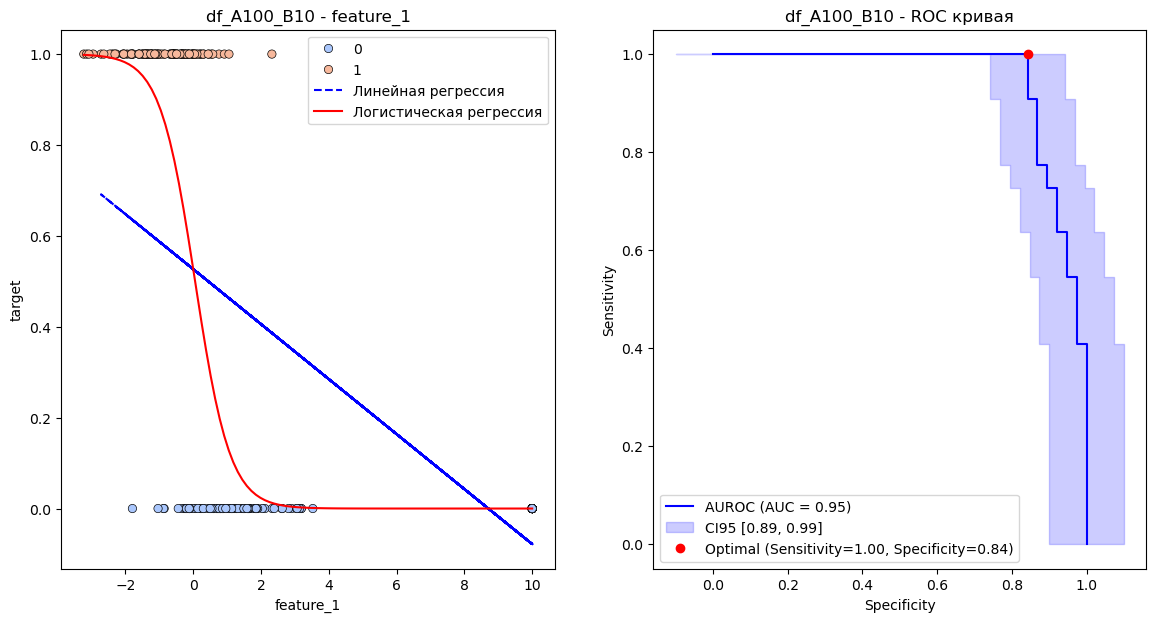

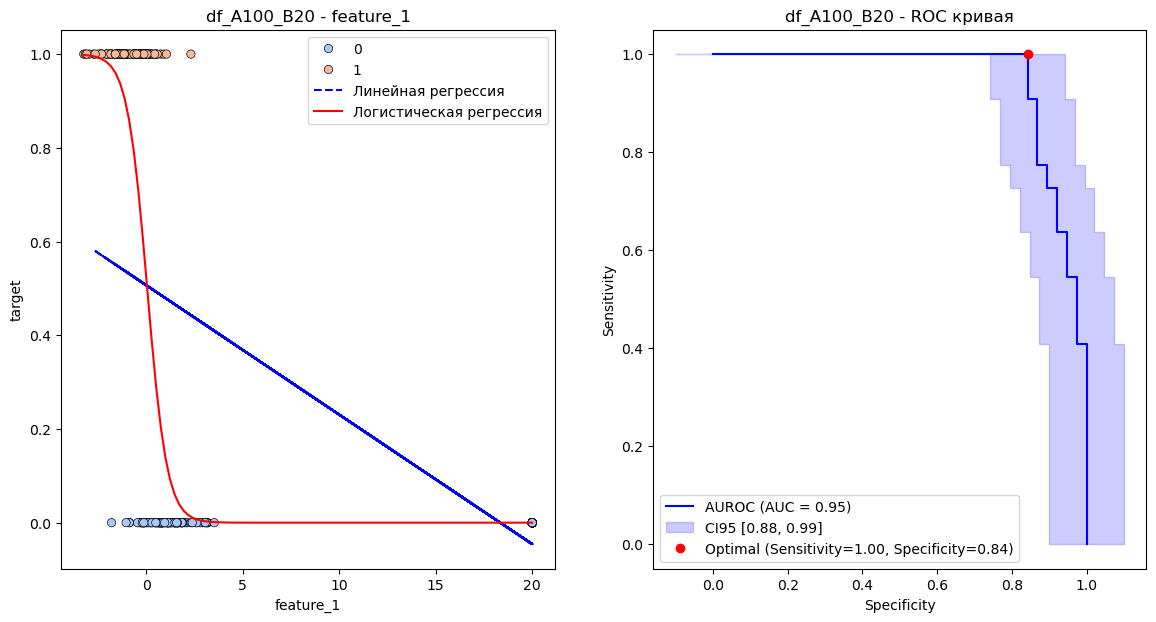

In [44]:
class1 = 0
class2 = 1
feature = 'feature_1'

def plot_regression_and_roc(df, title, class1=0, class2=1, feature='feature_1'):
    df_filtered = df[df['target'].isin([class1, class2])].copy()
    df_filtered['target'] = df_filtered['target'].apply(lambda x: 1 if x == class2 else 0)
    X = df_filtered[[feature]].values
    y = df_filtered['target'].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    lin_reg = LinearRegression().fit(X_train, y_train)
    log_reg = LogisticRegression().fit(X_train, y_train)

    lin_reg_pred = lin_reg.predict(X_test)
    log_reg_pred = log_reg.predict_proba(X_test)[:, 1]

    X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    log_reg_pred_range = log_reg.predict_proba(X_range)[:, 1]

    plt.figure(figsize=(14, 7))

    plt.subplot(1, 2, 1)
    sns.scatterplot(x=feature, y='target', data=df_filtered, hue='target', palette='coolwarm', marker='o', edgecolor='k')
    plt.plot(X_test, lin_reg_pred, 'b--', label='Линейная регрессия')
    plt.plot(X_range, log_reg_pred_range, 'r-', label='Логистическая регрессия')
    plt.title(f'{title} - {feature}')
    plt.ylabel('target')
    plt.legend()

    plt.subplot(1, 2, 2)
    fpr, tpr, _ = roc_curve(y_test, log_reg_pred)
    roc_auc = auc(fpr, tpr)
    
    sensitivity = tpr
    specificity = 1 - fpr

    plt.plot(specificity, sensitivity, color='blue', label=f'AUROC (AUC = {roc_auc:.2f})')
    # plt.plot([1, 0], [0, 1], 'grey', linestyle='--')  # Диагональ для сравнения

    bootstrapped_scores = [
        auc(*roc_curve(*resample(y_test, log_reg.predict_proba(X_test)[:, 1]))[:2])
        for _ in range(1000)
        if len(np.unique(resample(y_test))) > 1
    ]
    lower_ci, upper_ci = np.percentile(bootstrapped_scores, [2.5, 97.5])

    plt.fill_betweenx(sensitivity, specificity - 0.1, specificity + 0.1, color='blue', alpha=0.2, label=f'CI95 [{lower_ci:.2f}, {upper_ci:.2f}]')

    optimal_idx = np.argmax(sensitivity + specificity) 
    plt.plot(specificity[optimal_idx], sensitivity[optimal_idx], 'ro', label=f'Optimal (Sensitivity={sensitivity[optimal_idx]:.2f}, Specificity={specificity[optimal_idx]:.2f})')

    plt.title(f'{title} - ROC кривая')
    plt.xlabel('Specificity')
    plt.ylabel('Sensitivity')
    plt.legend(loc="lower left")
    plt.show()

for key, value in datasets.items():
    plot_regression_and_roc(value, f'{key}')

[5] Для выбранной пары классов (включая класс с повторенными объектами) на
всех признаках вычислить уравнение множественной линейной регрессии, где Y –
класс, Xi – признаки.
Используя полученные уравнения множественной линейной регрессии, на основе
каждого из датасетов df и df_A_B сформировать новые датасеты logdf и logdf_A_B,
в каждом из которых есть только один признак Х, сформированный на основе
соответствующего уравнения множественной линейной регрессии, а переменная Y
– отнесение к классу.

In [13]:
features = ['feature_1', 'feature_2', 'feature_3', 'feature_4']
def create_logdf(df, class1 = 0, class2 = 1):
    df_f = df[df['target'].isin([class1, class2])].copy()
    df_f['target'] = df_f['target'].apply(lambda x: 1 if x == class2 else 0)
    X = df_f[features].values
    y = df_f['target'].values
    lin_reg = LinearRegression().fit(X, y)
    y_pred = lin_reg.predict(X)

    logdf = pd.DataFrame({'X_regression': y_pred, 'target': y})
    return logdf

logdf = create_logdf(datasets['df_A0_B0'])
log_datasets = {'logdf': logdf}

for key, value in datasets.items():
    if key != 'df_A0_B0':
        log_datasets[f'log_{key}'] = create_logdf(value)

for key, value in log_datasets.items():
    print(f"Dataset: {key}")
    print(value.head()) #там точно есть 1)


Dataset: logdf
   X_regression  target
0     -0.002914       0
1      0.138556       0
2      0.151512       0
3      0.163374       0
4     -0.010694       0
Dataset: log_df_A1_B5
   X_regression  target
0      0.002022       0
1      0.159119       0
2      0.151242       0
3      0.159835       0
4     -0.012773       0
Dataset: log_df_A1_B10
   X_regression  target
0      0.002523       0
1      0.158196       0
2      0.151976       0
3      0.160949       0
4     -0.011801       0
Dataset: log_df_A1_B20
   X_regression  target
0      0.000155       0
1      0.148985       0
2      0.151941       0
3      0.162327       0
4     -0.011060       0
Dataset: log_df_A10_B5
   X_regression  target
0      0.009873       0
1      0.191830       0
2      0.150812       0
3      0.154205       0
4     -0.016080       0
Dataset: log_df_A10_B10
   X_regression  target
0      0.005042       0
1      0.167295       0
2      0.152192       0
3      0.159825       0
4     -0.012313       0
Datase

[6] Для каждого из датасетов logdf и logdf_A_B в своем пространстве Х-Y
(количественный признак-класс) построить и визуализировать объекты, линию
простой линейной регрессии и линию логистической регрессии. Регрессии строить
на паре Х-Y( количественный признак-класс).
Оценить качество работы полученных на основе логистической регрессии
классификаторов, используя ROC кривые и восстановив на графике ROC кривых
точку классификации Sensitivity-Specificity и доверительные интервалы CI95.
Все полученные графики возможно расположить в две колонки.

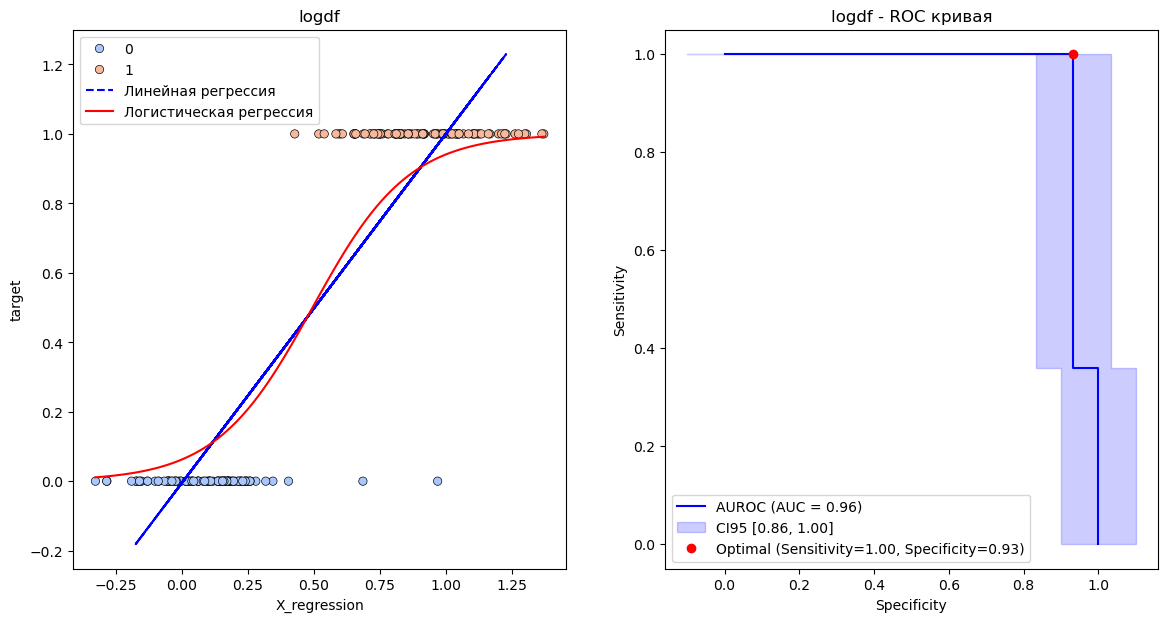

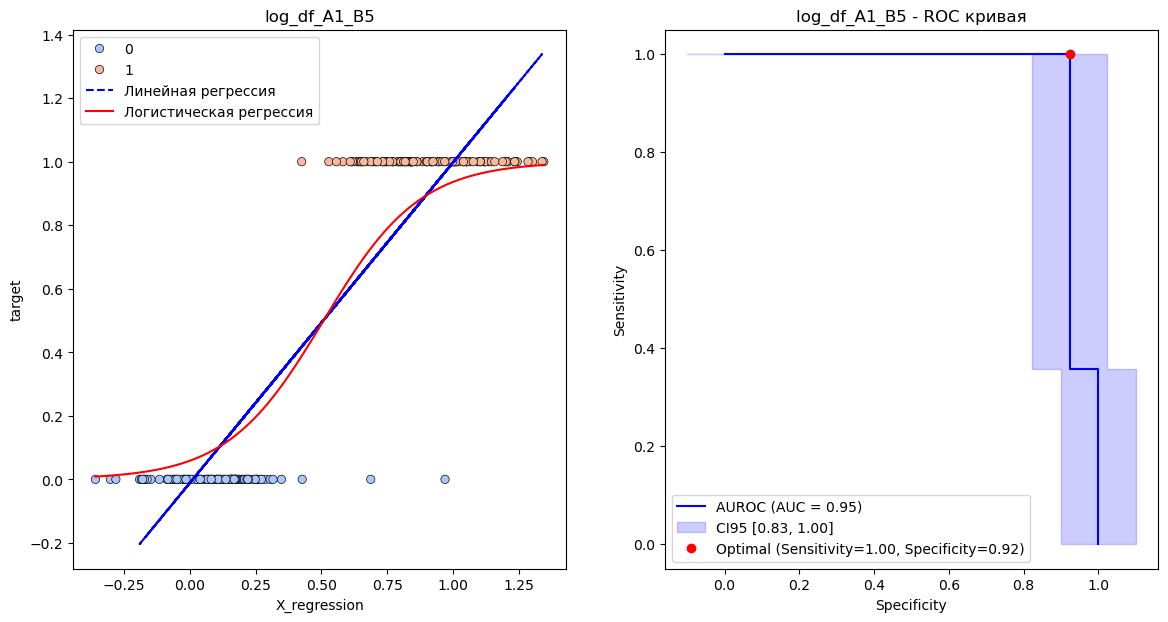

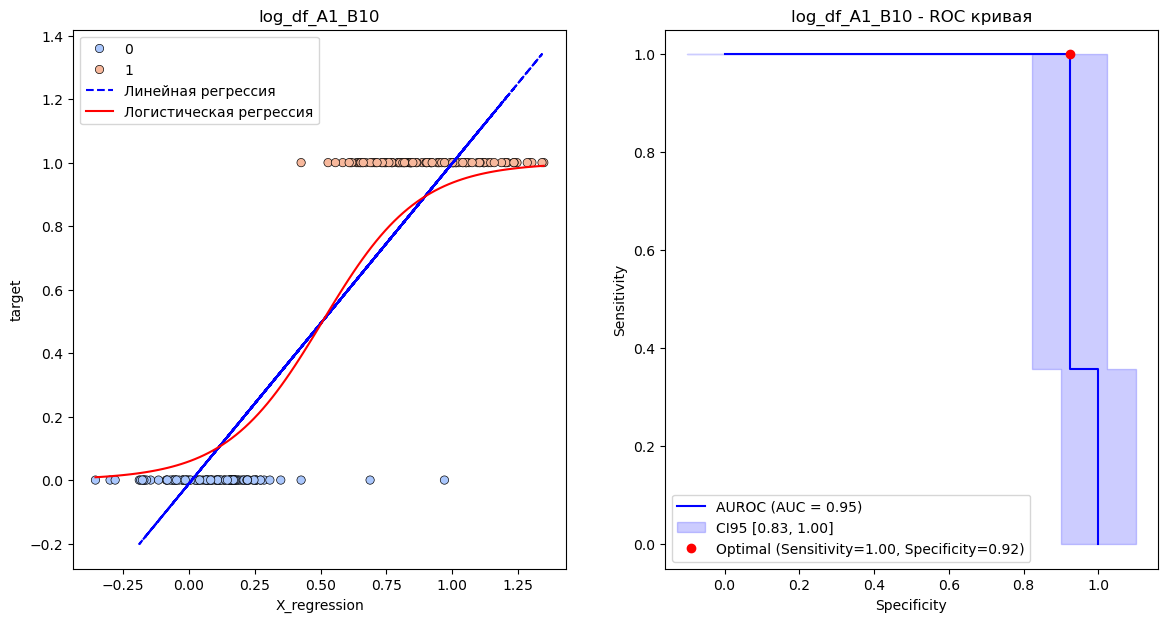

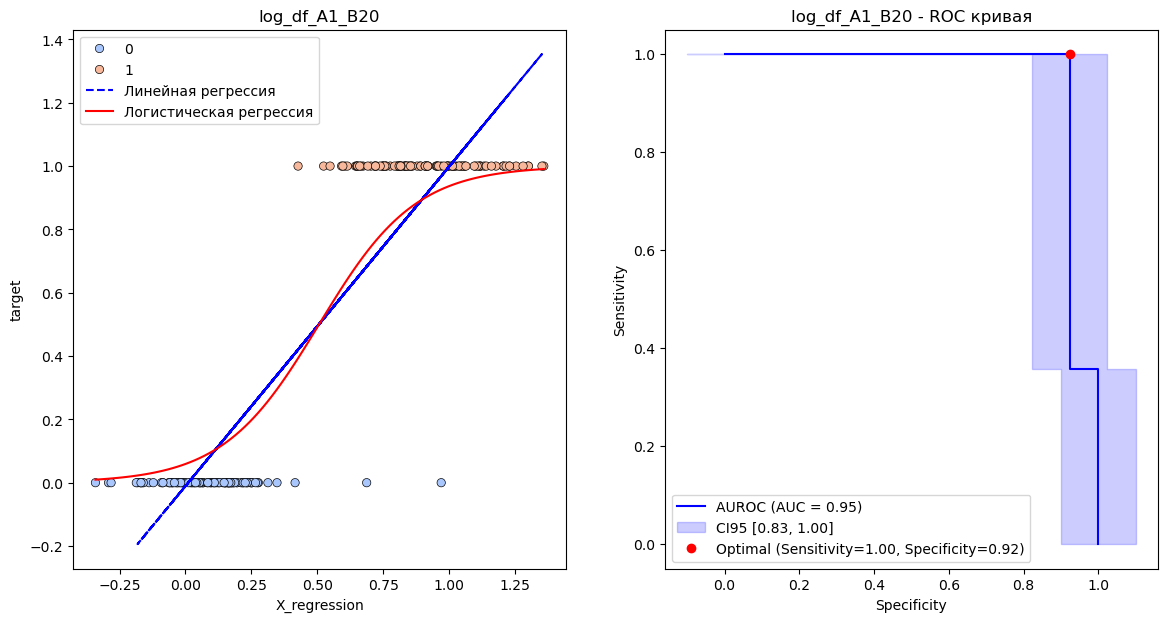

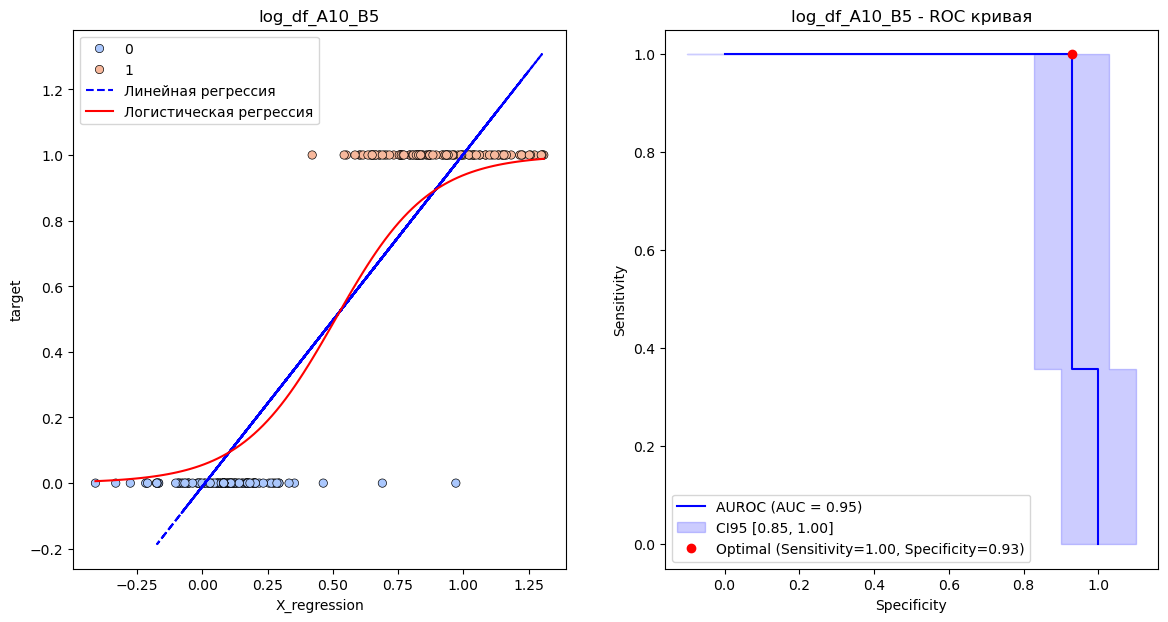

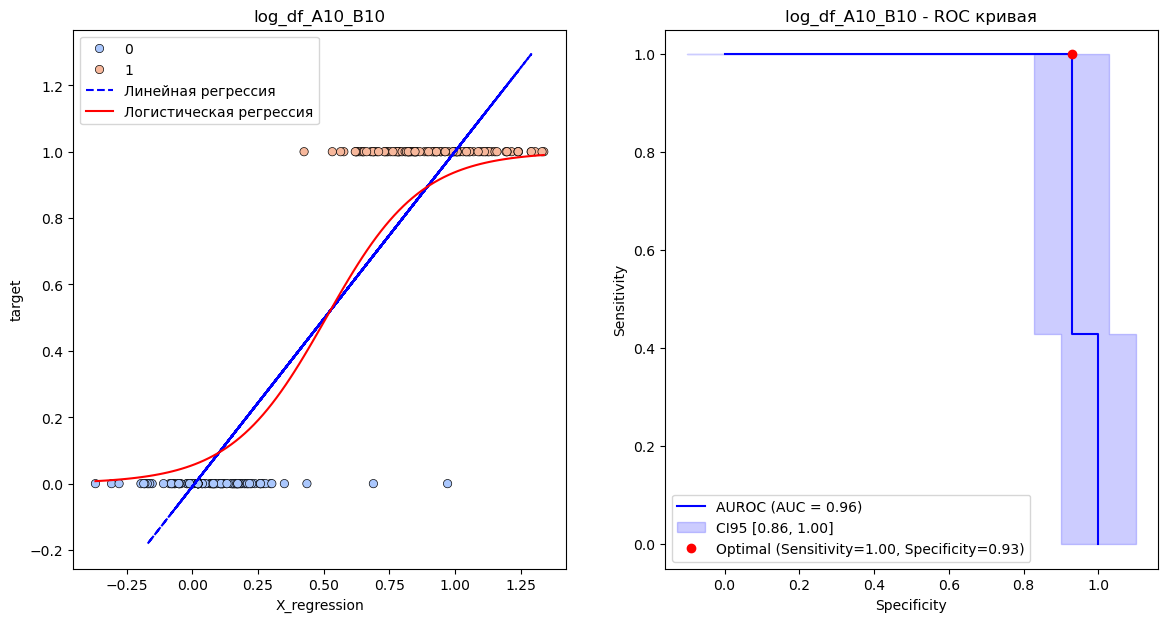

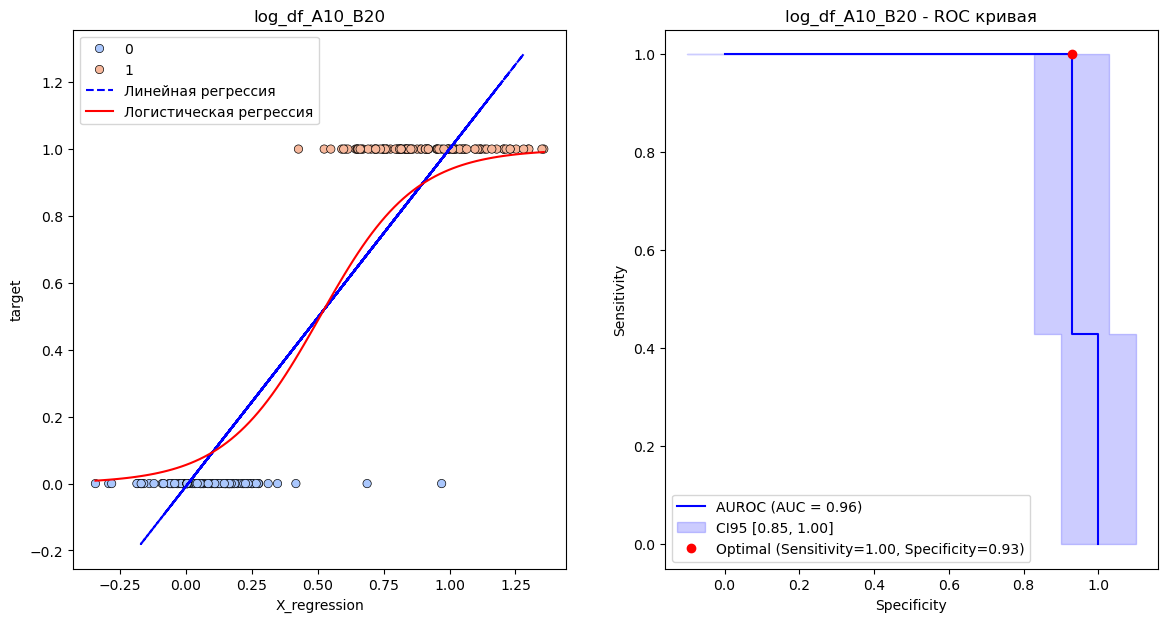

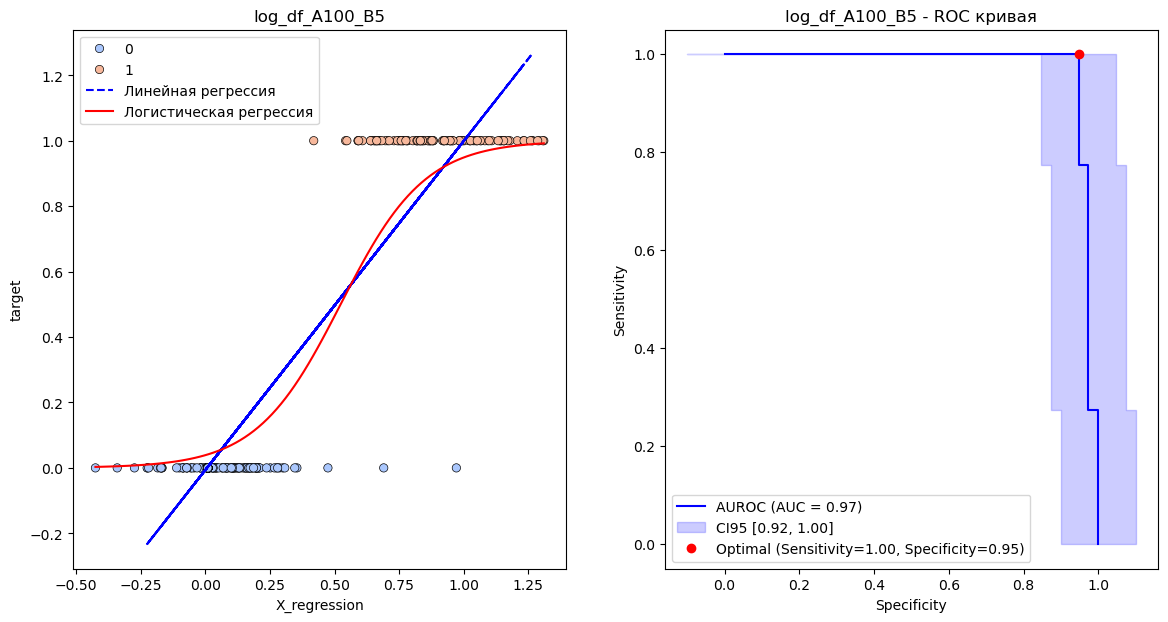

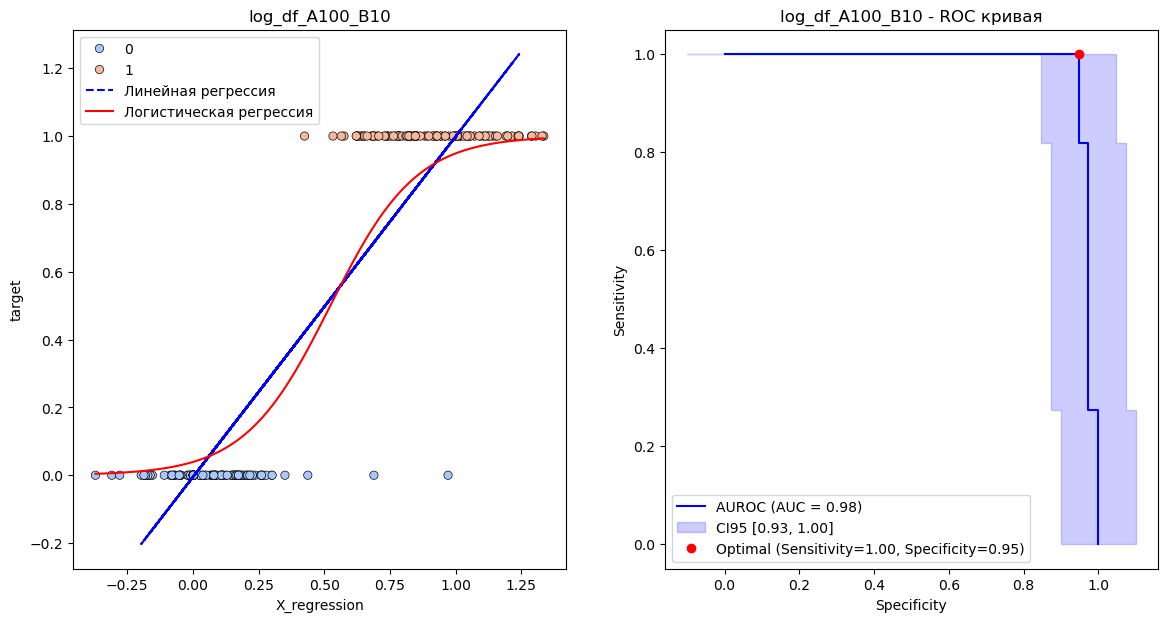

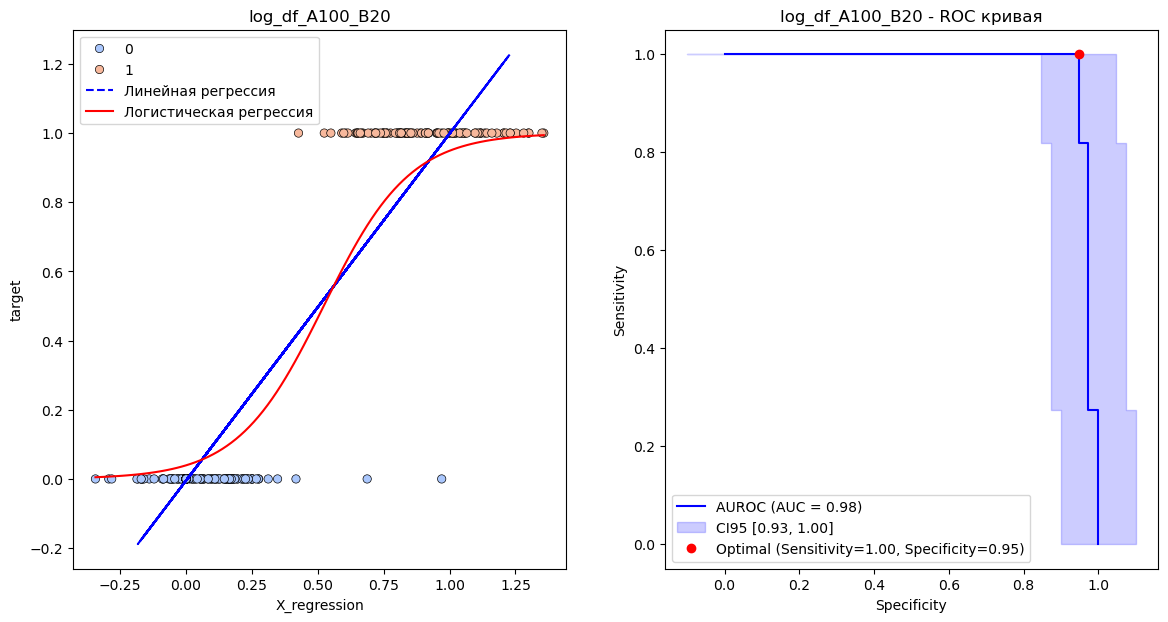

In [14]:
def plot_regression_and_roc(df, title, class1=0, class2=1):
    X = df[['X_regression']].values
    y = df['target'].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    lin_reg = LinearRegression().fit(X_train, y_train)
    log_reg = LogisticRegression().fit(X_train, y_train)

    lin_reg_pred = lin_reg.predict(X_test)
    log_reg_pred = log_reg.predict_proba(X_test)[:, 1]

    X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    log_reg_pred_range = log_reg.predict_proba(X_range)[:, 1]

    plt.figure(figsize=(14, 7))


    plt.subplot(1, 2, 1)
    sns.scatterplot(x='X_regression', y='target', data=df, hue='target', palette='coolwarm', marker='o', edgecolor='k')
    plt.plot(X_test, lin_reg_pred, 'b--', label='Линейная регрессия')
    plt.plot(X_range, log_reg_pred_range, 'r-', label='Логистическая регрессия')
    plt.title(f'{title}')
    plt.ylabel('target')
    plt.legend()

    plt.subplot(1, 2, 2)
    fpr, tpr, _ = roc_curve(y_test, log_reg_pred)
    roc_auc = auc(fpr, tpr)
    

    sensitivity = tpr  
    specificity = 1 - fpr  

    plt.plot(specificity, sensitivity, color='blue', label=f'AUROC (AUC = {roc_auc:.2f})')
    # plt.plot([1, 0], [0, 1], 'grey', linestyle='--') 

    bootstrapped_scores = [
        auc(*roc_curve(*resample(y_test, log_reg.predict_proba(X_test)[:, 1]))[:2])
        for _ in range(1000)
        if len(np.unique(resample(y_test))) > 1
    ]
    lower_ci, upper_ci = np.percentile(bootstrapped_scores, [2.5, 97.5])

    plt.fill_betweenx(sensitivity, specificity - 0.1, specificity + 0.1, color='blue', alpha=0.2, label=f'CI95 [{lower_ci:.2f}, {upper_ci:.2f}]')

    optimal_idx = np.argmax(sensitivity + specificity)
    plt.plot(specificity[optimal_idx], sensitivity[optimal_idx], 'ro', label=f'Optimal (Sensitivity={sensitivity[optimal_idx]:.2f}, Specificity={specificity[optimal_idx]:.2f})')

    # Заголовок и метки осей
    plt.title(f'{title} - ROC кривая')
    plt.xlabel('Specificity')
    plt.ylabel('Sensitivity')
    plt.legend(loc="lower left")
    plt.show()

# Построение графиков для каждого набора данных
for key, value in log_datasets.items():
    plot_regression_and_roc(value, f'{key}')

[7] Для выбранной пары классов (включая класс с повторенными объектами),
визуализировать один из датасетов df_A_B на всех парах переменных, построив
на графиках объекты, линии множественной линейной регрессии, разделение
классов на основе логистической регрессии решающей функцией с contour_plot
уровнями классификации.

/tmp/ipykernel_14474/2226884317.py:45: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(xx, yy, Z, levels=[0.5], colors='green', linestyles='--', label="Logistic Decision Boundary")
/tmp/ipykernel_14474/2226884317.py:45: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(xx, yy, Z, levels=[0.5], colors='green', linestyles='--', label="Logistic Decision Boundary")
/tmp/ipykernel_14474/2226884317.py:45: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(xx, yy, Z, levels=[0.5], colors='green', linestyles='--', label="Logistic Decision Boundary")
/tmp/ipykernel_14474/2226884317.py:45: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(xx, yy, Z, levels=[0.5], colors='green', linestyles='--', label="Logistic Decision Boundary")
/tmp/ipykernel_14474/2226884317.py:45: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(xx, yy, Z, levels=[0.5],

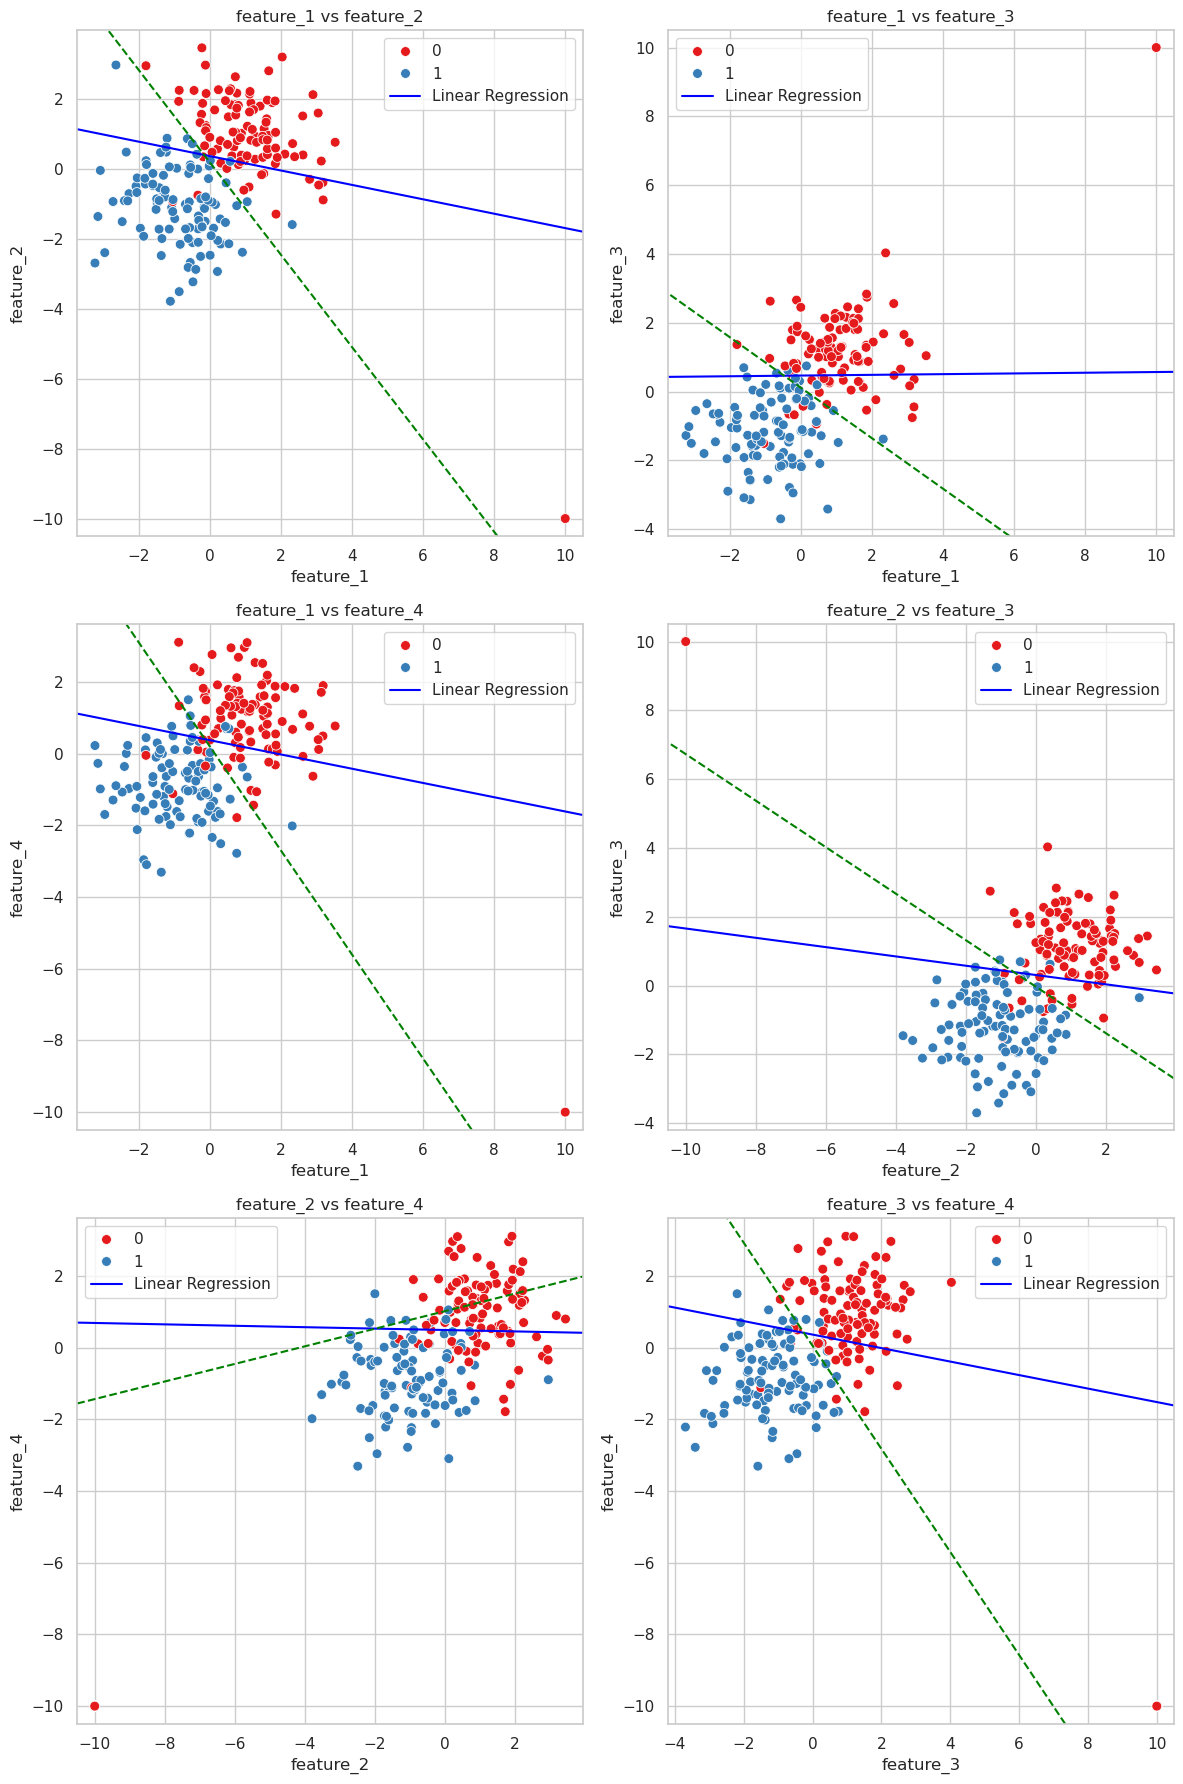

In [21]:
data = datasets['df_A100_B10']

data_filtered = data[data['target'].isin([0, 1])]

X = data_filtered[["feature_1", "feature_2", "feature_3", "feature_4"]]
y = data_filtered["target"]

sns.set(style="whitegrid")
feature_pairs = list(combinations(X.columns, 2))

num_pairs = len(feature_pairs)
num_cols = 2
num_rows = (num_pairs + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, num_rows * 6))
axes = axes.flatten()

for i, pair in enumerate(feature_pairs):
    feature_x, feature_y = pair
    ax = axes[i]

    X_pair = data_filtered[[feature_x, feature_y]].values

    lin_reg = LinearRegression()
    lin_reg.fit(X_pair, y)

    log_reg = LogisticRegression()
    log_reg.fit(X_pair, y)

    x_min, x_max = X_pair[:, 0].min() - 0.5, X_pair[:, 0].max() + 0.5
    y_min, y_max = X_pair[:, 1].min() - 0.5, X_pair[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = log_reg.predict_proba(grid)[:, 1]
    Z = Z.reshape(xx.shape)

    sns.scatterplot(x=feature_x, y=feature_y, hue="target", data=data_filtered, palette="Set1", s=50, ax=ax)

    x_vals = np.linspace(x_min, x_max, 100)
    y_vals = lin_reg.intercept_ + lin_reg.coef_[0] * x_vals + lin_reg.coef_[1]
    ax.plot(x_vals, y_vals, color="blue", label="Linear Regression")

    ax.contour(xx, yy, Z, levels=[0.5], colors='green', linestyles='--', label="Logistic Decision Boundary")

    ax.set_title(f"{feature_x} vs {feature_y}")
    ax.set_xlabel(feature_x)
    ax.set_ylabel(feature_y)
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Выберите номера выбросов из списка: 1, 2, 3, 4, 5, 6, 7, 8


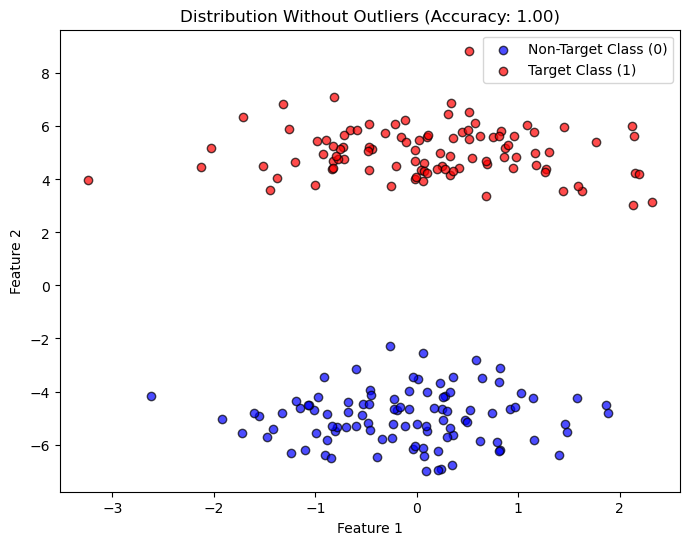

Accuracy without outliers: 1.00


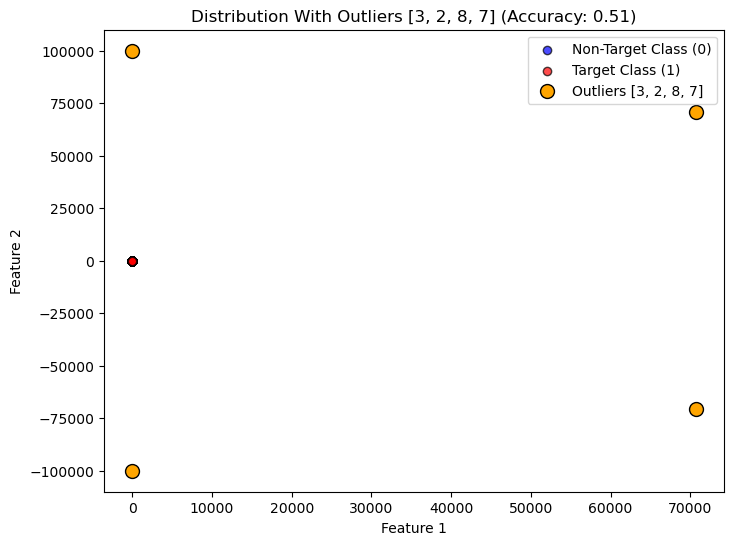

Accuracy with outliers [3, 2, 8, 7]: 0.51


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Генерация основного датасета
def generate_data(selected_outliers=None, target_class_weight=1.0):
    # Создаем два скопления точек: целевой (класс 1) и нецелевой (класс 0)
    X, y = make_blobs(n_samples=[100, 100], centers=[(0, -5), (0, 5)], cluster_std=1.0, random_state=42)
    
    # Добавляем выбросы по кругу на большом расстоянии
    n_outliers = 8
    radius = 1e5  # Большое расстояние
    angles = np.linspace(0, 2 * np.pi, n_outliers, endpoint=False)
    outliers_x = radius * np.cos(angles)
    outliers_y = radius * np.sin(angles)
    X_outliers = np.column_stack((outliers_x, outliers_y))
    y_outliers = np.ones(n_outliers)  # Все выбросы принадлежат целевому классу
    
    # Оставляем только те выбросы, номера которых указаны в selected_outliers
    if selected_outliers is not None:
        selected_indices = np.array(selected_outliers) - 1  # Номера точек на рисунке начинаются с 1
        X_outliers = X_outliers[selected_indices]
        y_outliers = y_outliers[selected_indices]
    else:
        X_outliers, y_outliers = np.array([]).reshape(0, 2), np.array([])  # Пустые выбросы
    
    # Объединяем основной датасет и выбранные выбросы
    X = np.vstack((X, X_outliers))
    y = np.hstack((y, y_outliers))
    
    # Создаем веса: обычные точки имеют вес 1, а выбросы получают больший вес
    sample_weights = np.ones_like(y)
    if selected_outliers:
        outlier_weight = (y == 1).sum()  # Вес выброса = количество точек целевого класса
        sample_weights[-len(selected_outliers):] = outlier_weight
    
    return X, y, sample_weights, selected_outliers

# Обучение и оценка логистической регрессии
def evaluate_logistic_regression(X, y, sample_weights):
    model = LogisticRegression()
    model.fit(X, y, sample_weight=sample_weights)  # Учитываем веса
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    return acc, model

# Визуализация данных
def plot_data(X, y, selected_outliers, title):
    plt.figure(figsize=(8, 6))
    
    # Отображаем целевой класс (1) и нецелевой класс (0)
    plt.scatter(X[y == 0, 0], X[y == 0, 1], color='blue', label='Non-Target Class (0)', alpha=0.7, edgecolors='k')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='red', label='Target Class (1)', alpha=0.7, edgecolors='k')
    
    # Если выбросы выбраны, выделяем их отдельно
    if selected_outliers is not None and len(selected_outliers) > 0:
        plt.scatter(X[-len(selected_outliers):, 0], X[-len(selected_outliers):, 1],
                    color='orange', s=100, label=f'Outliers {selected_outliers}', edgecolors='k')
    
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

# Основной блок выполнения
def main():
    print("Выберите номера выбросов из списка: 1, 2, 3, 4, 5, 6, 7, 8")
    selected_outliers = input("Введите номера выбросов через запятую (например, 1,3,5): ")
    
    if selected_outliers:
        selected_outliers = [int(i.strip()) for i in selected_outliers.split(",")]
    else:
        selected_outliers = []

    # Распределение без выбросов
    X_no_outliers, y_no_outliers, sample_weights_no_outliers, _ = generate_data(selected_outliers=None)
    acc_no_outliers, model_no_outliers = evaluate_logistic_regression(X_no_outliers, y_no_outliers, sample_weights_no_outliers)
    plot_data(X_no_outliers, y_no_outliers, selected_outliers=None,
              title=f"Distribution Without Outliers (Accuracy: {acc_no_outliers:.2f})")
    print(f"Accuracy without outliers: {acc_no_outliers:.2f}")
    
    # Распределение с выбранными выбросами
    X_with_outliers, y_with_outliers, sample_weights_with_outliers, selected_outliers = generate_data(selected_outliers=selected_outliers)
    acc_with_outliers, model_with_outliers = evaluate_logistic_regression(X_with_outliers, y_with_outliers, sample_weights_with_outliers)
    plot_data(X_with_outliers, y_with_outliers, selected_outliers=selected_outliers,
              title=f"Distribution With Outliers {selected_outliers} (Accuracy: {acc_with_outliers:.2f})")
    print(f"Accuracy with outliers {selected_outliers}: {acc_with_outliers:.2f}")

# Запуск
main()
